In [ ]:
"Bank Customer Lifetime Value Prediction and Segmentation Using Machine Learning, Deep Learning, and Generative AI"

In [32]:
# 1. IMPORT REQUIRED LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 2. DATASET LOADING & OVERVIEW

In [2]:
df = pd.read_csv('Bank Customer Churn Prediction.csv')
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# 3. DATA PREPROCESSING & MISSING VALUE CHECK

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [4]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [ ]:
# 4. CUSTOMER LIFETIME VALUE (CLV) SCORE CALCULATION

In [5]:
df['clv_score'] = (
    (df['credit_score'] / 850) * 40 +
    (df['balance'] / df['balance'].max()) * 30 +
    (df['tenure'] / 10) * 15 +
    (df['active_member']) * 10 +
    (df['products_number'] / 4) * 5
)

print("✅ CLV Score Created!")
print(df[['customer_id', 'clv_score']].head())

✅ CLV Score Created!
   customer_id  clv_score
0     15634602  43.379412
1     15647311  51.382709
2     15619304  58.464245
3     15701354  36.894118
4     15737888  69.257386


In [ ]:
# 5. CLV SCORE DISTRIBUTION ANALYSIS

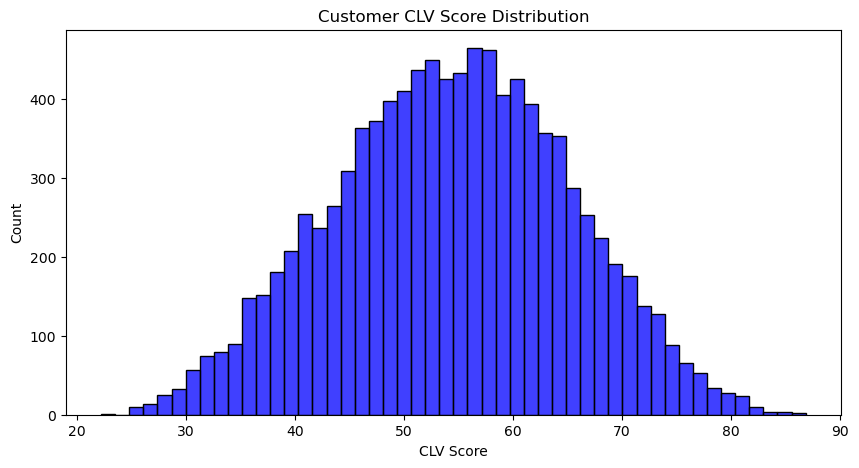

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df['clv_score'], bins=50, color='blue')
plt.title('Customer CLV Score Distribution')
plt.xlabel('CLV Score')
plt.ylabel('Count')
plt.show()

In [ ]:
# 6. CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING

In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[['clv_score', 'balance', 'credit_score']])

kmeans = KMeans(n_clusters=3, random_state=42)
df['segment'] = kmeans.fit_predict(df_scaled)

df['segment_label'] = df['segment'].map({
    0: 'Low Value',
    1: 'Mid Value',
    2: 'High Value'
})

print("Total customers segmented:", len(df))
print(df['segment_label'].value_counts())

Total customers segmented: 10000
segment_label
High Value    3711
Low Value     3291
Mid Value     2998
Name: count, dtype: int64


In [ ]:
# 7. CUSTOMER SEGMENT VISUALIZATION

C:\Users\kirut\AppData\Local\Temp\ipykernel_18964\3565216881.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='segment_label',


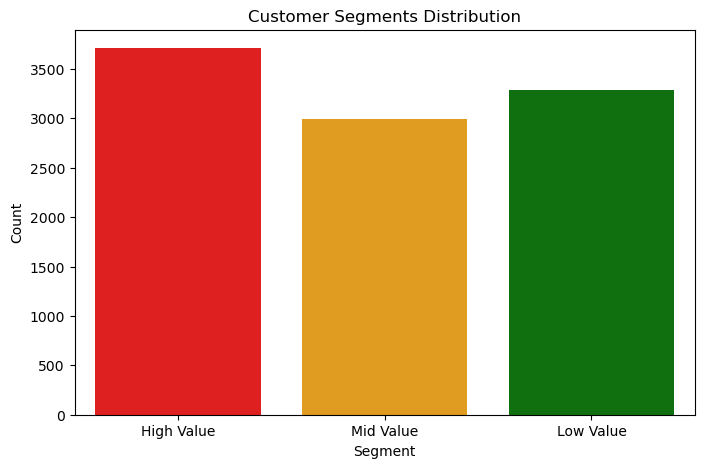

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='segment_label', 
              palette=['red','orange','green'])
plt.title('Customer Segments Distribution')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.show()

In [ ]:
# 8. MACHINE LEARNING MODEL (XGBOOST)

In [9]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Features & Target
X = df[['credit_score', 'age', 'tenure', 
        'balance', 'products_number', 
        'active_member', 'estimated_salary']]
y = df['clv_score']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("R2 Score:", round(r2_score(y_test, y_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 4))

R2 Score: 0.9963
MAE: 0.4866


In [ ]:
# 9. DEEP LEARNING MODEL (NEURAL NETWORK)

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Build Model
dl_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

dl_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
history = dl_model.fit(X_train, y_train, 
                        epochs=50, 
                        batch_size=32,
                        validation_split=0.2,
                        verbose=1)

C:\Users\kirut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 24273516.0000 - mae: 3121.8684 - val_loss: 123865.0703 - val_mae: 271.1881
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1169953.1250 - mae: 763.2786 - val_loss: 7510.0024 - val_mae: 74.4249
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 358795.7812 - mae: 417.7680 - val_loss: 5931.9336 - val_mae: 71.9438
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 168299.6250 - mae: 278.8536 - val_loss: 6855.1318 - val_mae: 76.1242
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 92106.1953 - mae: 202.6726 - val_loss: 3793.0100 - val_mae: 51.7759
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 71973.3203 - mae: 169.2772 - val_loss: 1942.6893 - val_mae: 39.7916
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 44641.4102 - mae: 136.4258 - val_loss: 4020.0813 - val_mae: 53.3023
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 29382.7324 - mae: 112.3750 - val_

In [12]:
# Evaluate DL Model
dl_pred = dl_model.predict(X_test)
from sklearn.metrics import r2_score, mean_absolute_error

print("DL R2 Score:", round(r2_score(y_test, dl_pred), 4))
print("DL MAE:", round(mean_absolute_error(y_test, dl_pred), 4))

# Compare ML vs DL
print("\n--- Model Comparison ---")
print(f"XGBoost R2: 0.9963")
print(f"Neural Network R2: {round(r2_score(y_test, dl_pred), 4)}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
DL R2 Score: -2.868
DL MAE: 19.2463

--- Model Comparison ---
XGBoost R2: 0.9963
Neural Network R2: -2.868


In [13]:
# Fix - Scale>> DL Train
from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))

# Retrain
dl_model2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])

dl_model2.compile(optimizer='adam', loss='mse')
dl_model2.fit(X_train_scaled, y_train_scaled, 
              epochs=50, batch_size=32, 
              validation_split=0.2, verbose=0)

# Evaluate
dl_pred2 = scaler_y.inverse_transform(dl_model2.predict(X_test_scaled))
print("Fixed DL R2:", round(r2_score(y_test, dl_pred2), 4))

C:\Users\kirut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fixed DL R2: 0.9822


In [ ]:
# 10. GENERATIVE AI CUSTOMER RECOMMENDATION (GEMINI AI)

In [14]:
!pip install google-genai


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from google import genai

client = genai.Client(api_key="YOUR_PASS_KEY")

def get_ai_advice(customer_data):
    prompt = f"""
    You are a bank financial advisor.
    Customer details:
    Credit Score: {customer_data['credit_score']}
    Balance: {customer_data['balance']}
    Age: {customer_data['age']}
    Tenure: {customer_data['tenure']} years
    CLV Score: {customer_data['clv_score']:.2f}
    Segment: {customer_data['segment_label']}
    Churn Risk: {'High' if customer_data['churn']==1 else 'Low'}
    Give 3 specific recommendations.
    """
    response = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=prompt
    )
    return response.text

customer = df.iloc[0]
print(get_ai_advice(customer))

Hello [Customer Name],

Thank you for providing your financial details. As your financial advisor, my goal is to help you achieve your financial aspirations and ensure you feel supported by our bank.

Looking at your profile, particularly your credit score of 619, your current balance of $0.00, and the indicated high churn risk, it's clear we have some immediate opportunities to strengthen your financial foundation and deepen our relationship. While your "High Value" segment status indicates your potential, let's work on converting that potential into tangible benefits for you.

Here are three specific recommendations tailored to your situation:

### **1. Kickstart an Emergency Fund with Automated Savings**

*   **Why:** A $0.00 balance means you currently lack a safety net for unexpected expenses, which can lead to increased stress and reliance on credit. Establishing an emergency fund is the foundational step for financial security. Given the high churn risk, building a positive habi

In [ ]:
# 10. PROJECT CONCLUSION

In [34]:
print("""
PROJECT CONCLUSION

1. Customer data was analyzed successfully.
2. CLV scores were calculated for all customers.
3. Customers were segmented into High, Mid, and Low Value groups.
4. XGBoost achieved excellent prediction performance.
5. Deep Learning model was developed and evaluated.
6. Gemini AI generated personalized customer recommendations.
7. The project supports customer retention and business decision-making.
""")


PROJECT CONCLUSION

1. Customer data was analyzed successfully.
2. CLV scores were calculated for all customers.
3. Customers were segmented into High, Mid, and Low Value groups.
4. XGBoost achieved excellent prediction performance.
5. Deep Learning model was developed and evaluated.
6. Gemini AI generated personalized customer recommendations.
7. The project supports customer retention and business decision-making.

